<a href="https://colab.research.google.com/github/Scyfize/deeplearningproject/blob/main/DeepLearningProject2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

# ==========================================
# 1. Load the Exact Pre-split Data
# ==========================================
print("Loading datasets...")
train_df = pd.read_csv('training.csv')
val_df = pd.read_csv('validation.csv')
test_df = pd.read_csv('test.csv')

# Extract text and labels from the dataframes
X_train_raw, y_train_raw = train_df['text'].values, train_df['label'].values
X_val_raw, y_val_raw = val_df['text'].values, val_df['label'].values
X_test_raw, y_test_raw = test_df['text'].values, test_df['label'].values

# ==========================================
# 2. Encode Labels & Map Strings
# ==========================================
# Fit the encoder ONLY on the training data to prevent data leakage
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train_raw)
y_val = encoder.transform(y_val_raw)
y_test = encoder.transform(y_test_raw)

num_classes = len(np.unique(y_train))

# Explicitly map the integer classes back to text strings
# so the classification_report formats beautifully without crashing.
emotion_mapping = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

# Safely extract the string names in the correct order determined by the encoder
target_names = [emotion_mapping.get(cls, str(cls)) for cls in encoder.classes_]
print(f"Detected {num_classes} emotion classes: {target_names}")

# ==========================================
# 3. Text Preprocessing
# ==========================================
vocab_size = 15000
max_length = 60 # Tweets are generally short

# Fit the Tokenizer ONLY on the training data
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

# Convert words to integer sequences and pad them to the same length
X_train_padded = pad_sequences(tokenizer.texts_to_sequences(X_train_raw), maxlen=max_length, padding='post', truncating='post')
X_val_padded = pad_sequences(tokenizer.texts_to_sequences(X_val_raw), maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=max_length, padding='post', truncating='post')

# ==========================================
# 4. Model 1: Base LSTM (The Baseline)
# ==========================================
model_1 = Sequential([
    Embedding(vocab_size, 64),
    LSTM(64), # Standard left-to-right sequence reading
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax') # Softmax for multi-class probability
])

model_1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("\n--- Training Base Model (Standard LSTM) ---")
# Train using the dedicated validation_data
history_1 = model_1.fit(X_train_padded, y_train, epochs=5,
                        validation_data=(X_val_padded, y_val), batch_size=64)

# ==========================================
# 5. Model 2: Improved Bi-LSTM with Dropout
# ==========================================
model_2 = Sequential([
    Embedding(vocab_size, 64),
    Bidirectional(LSTM(64)), # IMPROVEMENT 1: Reads forwards and backwards simultaneously
    Dropout(0.5),            # IMPROVEMENT 2: Prevents overfitting to the training set
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("\n--- Training Improved Model (Bi-LSTM + Dropout) ---")
history_2 = model_2.fit(X_train_padded, y_train, epochs=5,
                        validation_data=(X_val_padded, y_val), batch_size=64)

# ==========================================
# 6. Evaluate Both Models on the UNSEEN Test Set
# ==========================================
print("\n=== FINAL EVALUATION ON TEST.CSV ===")

print("\n--- Base Model 1 (Standard LSTM) Results ---")
# Predict and grab the highest probability class
y_pred_1 = np.argmax(model_1.predict(X_test_padded), axis=1)
# zero_division=0 silences warnings if the weak model misses a class entirely
print(classification_report(y_test, y_pred_1, target_names=target_names, zero_division=0))

print("\n--- Improved Model 2 (Bi-LSTM + Dropout) Results ---")
y_pred_2 = np.argmax(model_2.predict(X_test_padded), axis=1)
print(classification_report(y_test, y_pred_2, target_names=target_names, zero_division=0))

AttributeError: partially initialized module 'jax' has no attribute '_src' (most likely due to a circular import)


Generating Training History Plots...


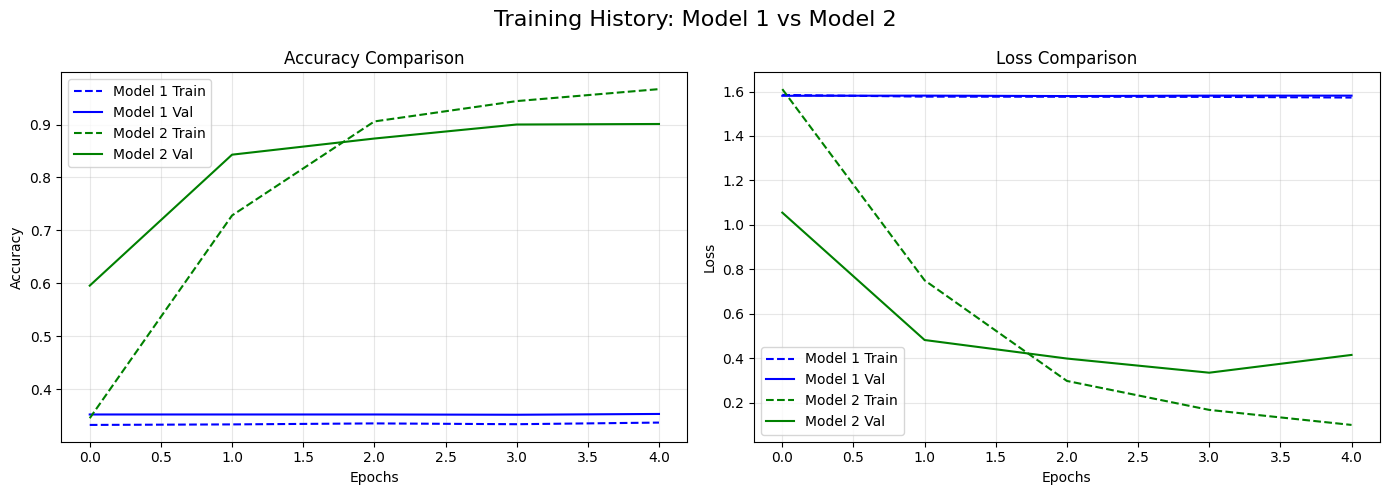


Generating Confusion Matrices...


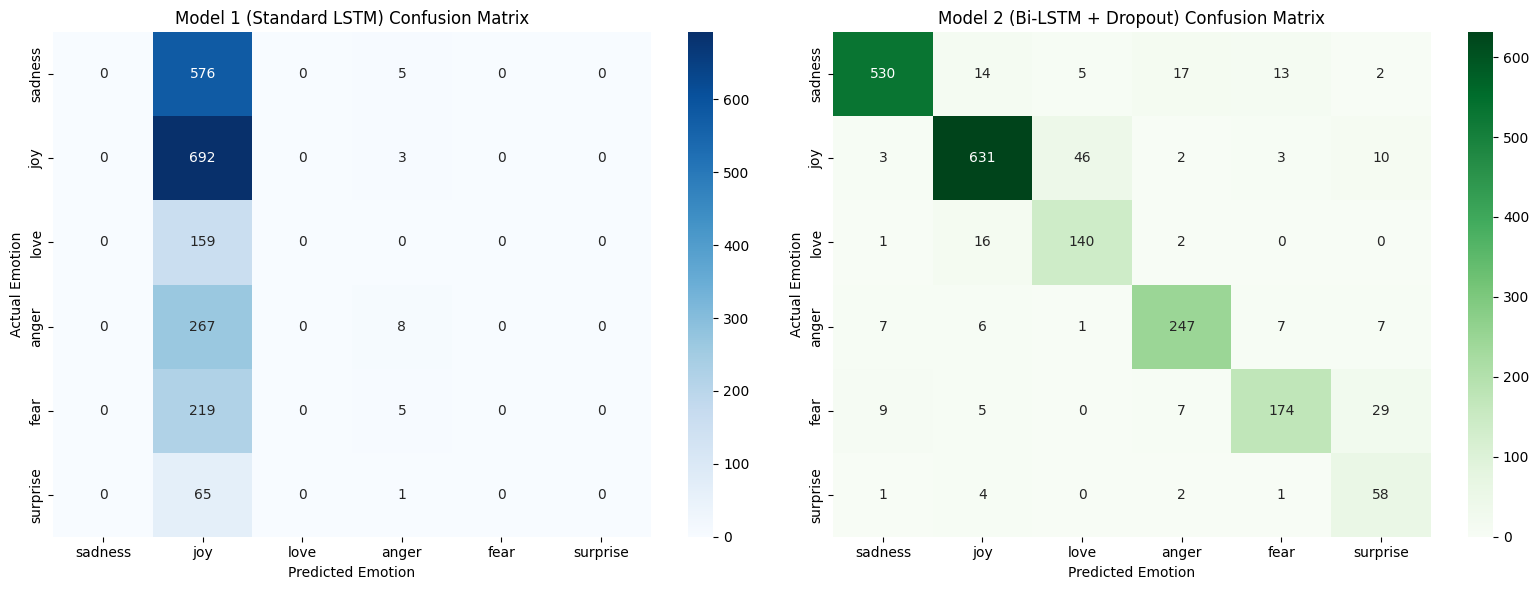

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# 8. Visualizing Training History
# ==========================================
def plot_history(history_1, history_2, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Accuracy
    axes[0].plot(history_1.history['accuracy'], label='Model 1 Train', color='blue', linestyle='--')
    axes[0].plot(history_1.history['val_accuracy'], label='Model 1 Val', color='blue')
    axes[0].plot(history_2.history['accuracy'], label='Model 2 Train', color='green', linestyle='--')
    axes[0].plot(history_2.history['val_accuracy'], label='Model 2 Val', color='green')
    axes[0].set_title(f'Accuracy Comparison')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Loss
    axes[1].plot(history_1.history['loss'], label='Model 1 Train', color='blue', linestyle='--')
    axes[1].plot(history_1.history['val_loss'], label='Model 1 Val', color='blue')
    axes[1].plot(history_2.history['loss'], label='Model 2 Train', color='green', linestyle='--')
    axes[1].plot(history_2.history['val_loss'], label='Model 2 Val', color='green')
    axes[1].set_title(f'Loss Comparison')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("\nGenerating Training History Plots...")
plot_history(history_1, history_2, "Training History: Model 1 vs Model 2")

# ==========================================
# 9. Visualizing Confusion Matrices
# ==========================================
def plot_confusion_matrices(y_true, y_pred_1, y_pred_2, labels):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Model 1 Matrix
    cm_1 = confusion_matrix(y_true, y_pred_1)
    sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=labels, yticklabels=labels)
    axes[0].set_title("Model 1 (Standard LSTM) Confusion Matrix")
    axes[0].set_xlabel("Predicted Emotion")
    axes[0].set_ylabel("Actual Emotion")

    # Model 2 Matrix
    cm_2 = confusion_matrix(y_true, y_pred_2)
    sns.heatmap(cm_2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=labels, yticklabels=labels)
    axes[1].set_title("Model 2 (Bi-LSTM + Weights) Confusion Matrix")
    axes[1].set_xlabel("Predicted Emotion")
    axes[1].set_ylabel("Actual Emotion")

    plt.tight_layout()
    plt.show()

print("\nGenerating Confusion Matrices...")
plot_confusion_matrices(y_test, y_pred_1, y_pred_2, target_names)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

# ==========================================
# 1. Load the Exact Pre-split Data
# ==========================================
print("Loading datasets...")
train_df = pd.read_csv('training.csv')
val_df = pd.read_csv('validation.csv')
test_df = pd.read_csv('test.csv')

# Extract text and labels from the dataframes
X_train_raw, y_train_raw = train_df['text'].values, train_df['label'].values
X_val_raw, y_val_raw = val_df['text'].values, val_df['label'].values
X_test_raw, y_test_raw = test_df['text'].values, test_df['label'].values

# ==========================================
# 2. Encode Labels & Map Strings
# ==========================================
# Fit the encoder ONLY on the training data to prevent data leakage
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train_raw)
y_val = encoder.transform(y_val_raw)
y_test = encoder.transform(y_test_raw)

num_classes = len(np.unique(y_train))

# Explicitly map the integer classes back to text strings
emotion_mapping = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
target_names = [emotion_mapping.get(cls, str(cls)) for cls in encoder.classes_]
print(f"Detected {num_classes} emotion classes: {target_names}")

# ==========================================
# 3. Text Preprocessing
# ==========================================
vocab_size = 15000
max_length = 60 # Tweets are generally short

# Fit the Tokenizer ONLY on the training data
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

# Convert words to integer sequences and pad them
X_train_padded = pad_sequences(tokenizer.texts_to_sequences(X_train_raw), maxlen=max_length, padding='post', truncating='post')
X_val_padded = pad_sequences(tokenizer.texts_to_sequences(X_val_raw), maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=max_length, padding='post', truncating='post')

# ==========================================
# 4. Compute Class Weights (MOVED UP)
# ==========================================
print("\nCalculating Class Weights to handle imbalance...")
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary format required by Keras
class_weight_dict = dict(enumerate(class_weights))

for emotion, weight in zip(target_names, class_weights):
    print(f"{emotion} weight: {weight:.2f}")

# ==========================================
# 5. Model 1: Base LSTM (The Baseline + Weights)
# ==========================================
model_1 = Sequential([
    Embedding(vocab_size, 64),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("\n--- Training Base Model (Standard LSTM) ---")
# Added class weights to Model 1
history_1 = model_1.fit(X_train_padded, y_train, epochs=5,
                        validation_data=(X_val_padded, y_val),
                        batch_size=64,
                        class_weight=class_weight_dict)

# ==========================================
# 6. Model 2: Improved Bi-LSTM + Dropout + Weights
# ==========================================
model_2 = Sequential([
    Embedding(vocab_size, 64),
    Bidirectional(LSTM(64)), # Reads forwards and backwards simultaneously
    Dropout(0.5),            # Prevents overfitting
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("\n--- Training Improved Model (Bi-LSTM + Dropout) ---")
history_2 = model_2.fit(X_train_padded, y_train, epochs=5,
                        validation_data=(X_val_padded, y_val),
                        batch_size=64,
                        class_weight=class_weight_dict)

# ==========================================
# 7. Evaluate Both Models on the UNSEEN Test Set
# ==========================================
print("\n=== FINAL EVALUATION ON TEST.CSV ===")

print("\n--- Base Model 1 (Standard LSTM) Results ---")
y_pred_1 = np.argmax(model_1.predict(X_test_padded), axis=1)
print(classification_report(y_test, y_pred_1, target_names=target_names, zero_division=0))

print("\n--- Improved Model 2 (Bi-LSTM + Dropout) Results ---")
y_pred_2 = np.argmax(model_2.predict(X_test_padded), axis=1)
print(classification_report(y_test, y_pred_2, target_names=target_names, zero_division=0))

Loading datasets...
Detected 6 emotion classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Calculating Class Weights to handle imbalance...
sadness weight: 0.57
joy weight: 0.50
love weight: 2.04
anger weight: 1.24
fear weight: 1.38
surprise weight: 4.66

--- Training Base Model (Standard LSTM) ---
Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1546 - loss: 1.7925 - val_accuracy: 0.1375 - val_loss: 1.7949
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1465 - loss: 1.7919 - val_accuracy: 0.0890 - val_loss: 1.7934
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0961 - loss: 1.7922 - val_accuracy: 0.0405 - val_loss: 1.7935
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1687 - loss: 1.7924 - val_accuracy: 0.0420 - val_loss: 1.7945
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1381 - loss: 1.7918 - val_accuracy: 0.1375 - val_loss: 1.8040

--- Training Improved Model (Bi-LSTM + Dropout) --


Generating Training History Plots...


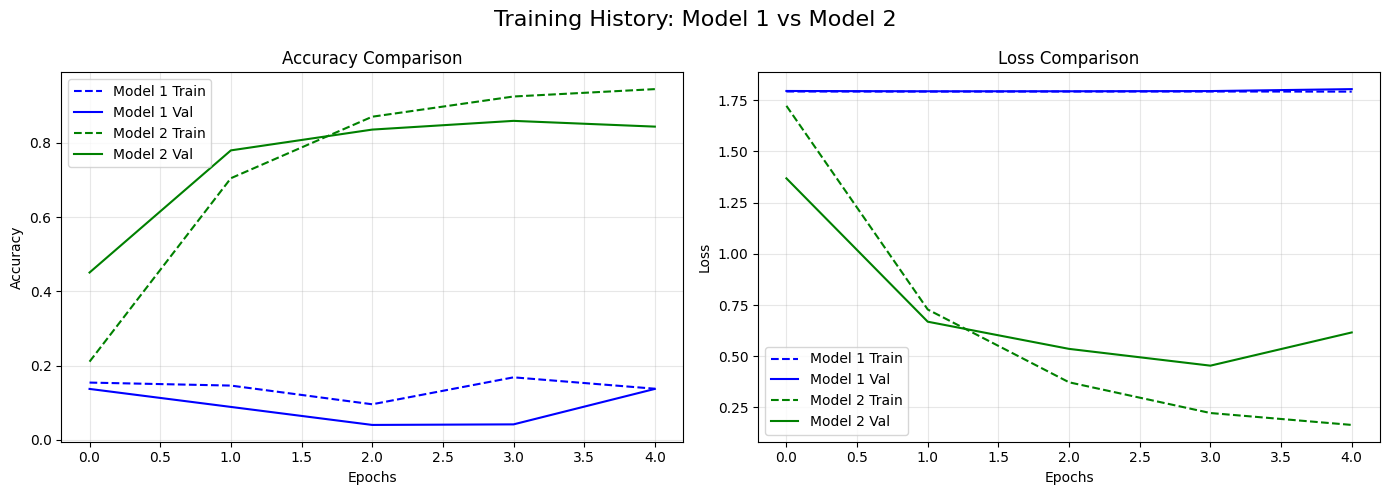


Generating Confusion Matrices...


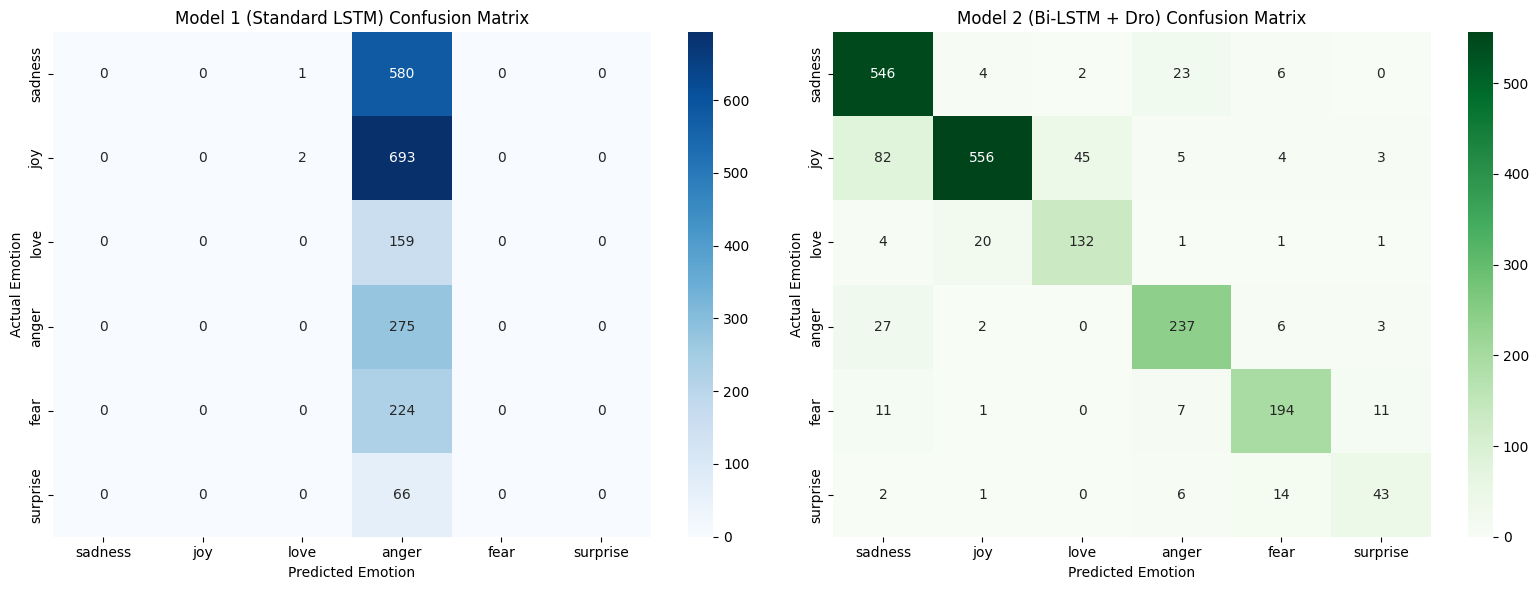

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# 8. Visualizing Training History
# ==========================================
def plot_history(history_1, history_2, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Accuracy
    axes[0].plot(history_1.history['accuracy'], label='Model 1 Train', color='blue', linestyle='--')
    axes[0].plot(history_1.history['val_accuracy'], label='Model 1 Val', color='blue')
    axes[0].plot(history_2.history['accuracy'], label='Model 2 Train', color='green', linestyle='--')
    axes[0].plot(history_2.history['val_accuracy'], label='Model 2 Val', color='green')
    axes[0].set_title(f'Accuracy Comparison')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Loss
    axes[1].plot(history_1.history['loss'], label='Model 1 Train', color='blue', linestyle='--')
    axes[1].plot(history_1.history['val_loss'], label='Model 1 Val', color='blue')
    axes[1].plot(history_2.history['loss'], label='Model 2 Train', color='green', linestyle='--')
    axes[1].plot(history_2.history['val_loss'], label='Model 2 Val', color='green')
    axes[1].set_title(f'Loss Comparison')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("\nGenerating Training History Plots...")
plot_history(history_1, history_2, "Training History: Model 1 vs Model 2")

# ==========================================
# 9. Visualizing Confusion Matrices
# ==========================================
def plot_confusion_matrices(y_true, y_pred_1, y_pred_2, labels):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Model 1 Matrix
    cm_1 = confusion_matrix(y_true, y_pred_1)
    sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=labels, yticklabels=labels)
    axes[0].set_title("Model 1 (Standard LSTM) Confusion Matrix")
    axes[0].set_xlabel("Predicted Emotion")
    axes[0].set_ylabel("Actual Emotion")

    # Model 2 Matrix
    cm_2 = confusion_matrix(y_true, y_pred_2)
    sns.heatmap(cm_2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=labels, yticklabels=labels)
    axes[1].set_title("Model 2 (Bi-LSTM + Dro) Confusion Matrix")
    axes[1].set_xlabel("Predicted Emotion")
    axes[1].set_ylabel("Actual Emotion")

    plt.tight_layout()
    plt.show()

print("\nGenerating Confusion Matrices...")
plot_confusion_matrices(y_test, y_pred_1, y_pred_2, target_names)

/tmp/ipykernel_3832/48258493.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


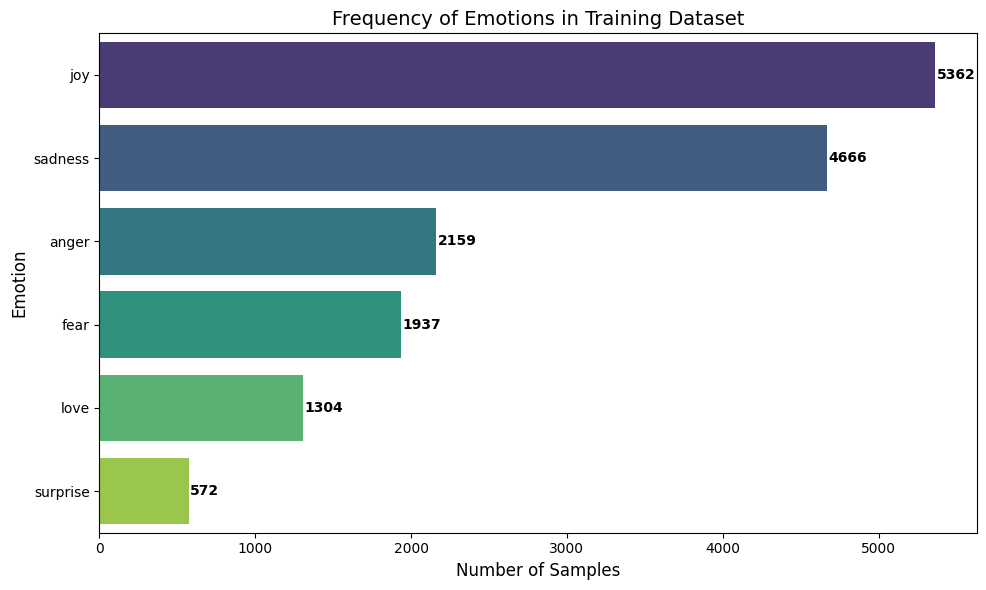

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('training.csv')

# 2. Define your mapping
emotion_mapping = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

# 3. Create a new column with the string names for the chart
# This looks at the 'label' column and replaces the number with the word
df['emotion_name'] = df['label'].map(emotion_mapping)

# 4. Count the occurrences
counts = df['emotion_name'].value_counts()

# 5. Plot the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=counts.values, y=counts.index, palette='viridis')

# Add styling and labels
plt.title('Frequency of Emotions in Training Dataset', fontsize=14)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Emotion', fontsize=12)

# Add exact numbers to the bars
for i, v in enumerate(counts.values):
    plt.text(v + 10, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()